## 2.3. Содержание ноутбука HW08-09.ipynb (обязательно)

## 2.3.1. Импорты, seed и устройство

In [1]:
import os
import math
import time
import random
from dataclasses import dataclass
from torchvision import transforms
import torch 
import torch.nn as nn
import torchvision 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import DataLoader, random_split

RANDOM_STATE = 42
a = torch.manual_seed(RANDOM_STATE)
b = np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cpu


### 2.3.2. Данные и DataLoader

In [2]:
# 1.Определяем trasform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5))
])

In [3]:
# 2.Загружаем датасет 
train = torchvision.datasets.CIFAR10(
    root = "./data", train = True, download = True, transform = transform
)

test = torchvision.datasets.CIFAR10(
    root = "./data", train = False, download = True, transform = transform
)

In [4]:
# 3.Разбиение train/val
val_ratio = 0.2
val_size = int(len(train) * val_ratio)
train_size = len(train) - val_size

generator = torch.Generator().manual_seed(RANDOM_STATE)
train_dataset, val_dataset = random_split(
    train, [train_size, val_size], generator=generator
)

In [5]:
# DataLoaders
BATCH_SIZE = 64
NUM_WORKERS = 0 if os.name == 'nt' else 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

In [7]:
# 5. Sanity-check
dataiter = iter(train_loader)
images, labels = next(dataiter)

print(f"\n--- Sanity Check ---")
print(f"Форма батча с картинками: {images.shape}")
print(f"Форма батча с метками: {labels.shape}")
print(f"Тип данных картинок: {images.dtype}")
print(f"Тип данных меток: {labels.dtype}")


--- Sanity Check ---
Форма батча с картинками: torch.Size([64, 3, 32, 32])
Форма батча с метками: torch.Size([64])
Тип данных картинок: torch.float32
Тип данных меток: torch.int64


### 2.3.3.Модель MLP и цикл обучения

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)

Вход: torch.Size([64, 3, 32, 32])
Выход (logits): torch.Size([64, 10])

Запускаем обучение базовой модели
Начинаем обучение...
------------------------------------------------------------
Эпоха  1/10 | Train loss: 1.6656, acc: 0.4076 | Val loss: 1.5369, acc: 0.4564
Эпоха  2/10 | Train loss: 1.4587, acc: 0.4857 | Val loss: 1.4670, acc: 0.4832
Эпоха  3/10 | Train loss: 1.3479, acc: 0.5250 | Val loss: 1.4180, acc: 0.5037
Эпоха  4/10 | Train loss: 1.2637, acc: 0.5518 | Val loss: 1.3921, acc: 0.5147
Эпоха  5/10 | Train loss: 1.1815, acc: 0.5844 | Val loss: 1.3868, acc: 0.5196
Эпоха  6/10 | Train loss: 1.1110, acc: 0.6063 | Val loss: 1.4271, acc: 0.5147
Эпоха  7/10 | Train loss: 1.0437, acc: 0.6286 | Val

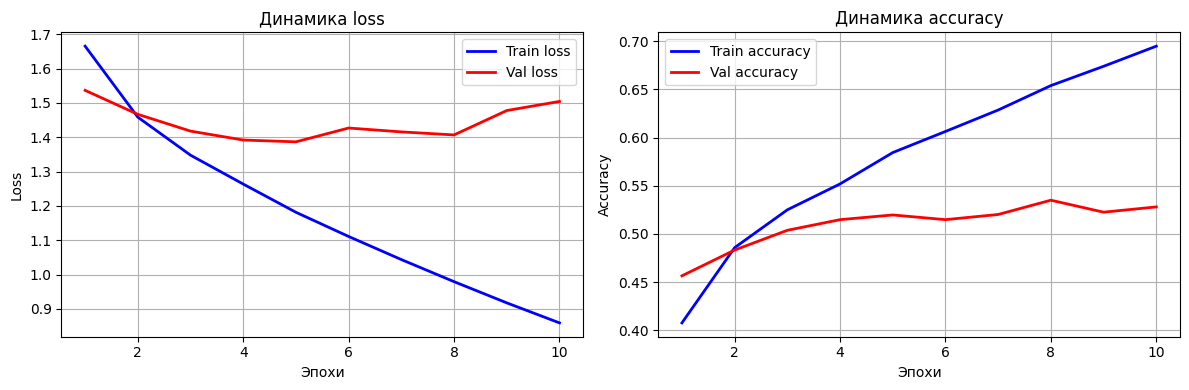


Итоговые результаты:
Лучшая val accuracy: 0.5349
Финальная val accuracy: 0.5280


In [9]:
# Создаем класс MLP
class MLP(nn.Module):
    def __init__(self, input_size=3*32*32, hidden_sizes=[256, 128], num_classes=10):
        super().__init__()
        
        # Строим слои последовательно
        layers = []
        
        # Преобразуем картинку в вектор
        layers.append(nn.Flatten())
        
        # Первый скрытый слой
        layers.append(nn.Linear(input_size, hidden_sizes[0]))
        layers.append(nn.ReLU())
        
        # Второй скрытый слой
        layers.append(nn.Linear(hidden_sizes[0], hidden_sizes[1]))
        layers.append(nn.ReLU())
        
        # Выходной слой
        layers.append(nn.Linear(hidden_sizes[1], num_classes))
        
        # Объединяем все в Sequential
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

# Проверяем, что модель работает
model = MLP().to(DEVICE)
print(model)

# Проверяем форму выхода
test_batch, _ = next(iter(train_loader))
test_batch = test_batch.to(DEVICE)
with torch.no_grad():
    output = model(test_batch)
print(f"\nВход: {test_batch.shape}")
print(f"Выход (logits): {output.shape}")

# Функция для подсчета accuracy
def calculate_accuracy(logits, labels):
    predictions = torch.argmax(logits, dim=1)
    correct = (predictions == labels).sum().item()
    return correct / len(labels)

# Функция для обучения на одной эпохе
def train_one_epoch(model, train_loader, optimizer, criterion):
    model.train()  # Включаем режим обучения
    
    total_loss = 0.0
    total_acc = 0.0
    num_batches = 0
    
    for images, labels in train_loader:
        # Перемещаем данные на устройство
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        # Обнуляем градиенты
        optimizer.zero_grad()
        
        # Прямой проход
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Обратный проход
        loss.backward()
        optimizer.step()
        
        # Собираем статистику
        total_loss += loss.item()
        total_acc += calculate_accuracy(outputs, labels)
        num_batches += 1
    
    # Усредняем результаты
    avg_loss = total_loss / num_batches
    avg_acc = total_acc / num_batches
    
    return avg_loss, avg_acc

# Функция для оценки на валидации/тесте
@torch.no_grad()  # Не считаем градиенты
def evaluate(model, val_loader, criterion):
    model.eval()  # Включаем режим оценки
    
    total_loss = 0.0
    total_acc = 0.0
    num_batches = 0
    
    for images, labels in val_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        total_loss += loss.item()
        total_acc += calculate_accuracy(outputs, labels)
        num_batches += 1
    
    avg_loss = total_loss / num_batches
    avg_acc = total_acc / num_batches
    
    return avg_loss, avg_acc

# Основная функция для обучения
def train(model, train_loader, val_loader, optimizer, criterion, num_epochs=10):
    # Словарь для хранения истории обучения
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    print("Начинаем обучение...")
    print("-" * 60)
    
    for epoch in range(num_epochs):
        # Обучаем одну эпоху
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        
        # Оцениваем на валидации
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        
        # Сохраняем историю
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Выводим прогресс
        print(f"Эпоха {epoch+1:2d}/{num_epochs} | "
              f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
              f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")
    
    
    return history

# Тестируем нашу модель
print("\n" + "="*60)
print("Запускаем обучение базовой модели")
print("="*60)

# Создаем новую модель для эксперимента
baseline_model = MLP().to(DEVICE)

# Определяем функцию потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=0.001)

# Обучаем модель
history = train(
    model=baseline_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=10
)

# Строим графики
def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    # График loss
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Train loss', linewidth=2)
    plt.plot(epochs, history['val_loss'], 'r-', label='Val loss', linewidth=2)
    plt.xlabel('Эпохи')
    plt.ylabel('Loss')
    plt.title('Динамика loss')
    plt.legend()
    plt.grid(True)
    
    # График accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-', label='Train accuracy', linewidth=2)
    plt.plot(epochs, history['val_acc'], 'r-', label='Val accuracy', linewidth=2)
    plt.xlabel('Эпохи')
    plt.ylabel('Accuracy')
    plt.title('Динамика accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# Строим графики
plot_training_history(history)

# Смотрим итоговые метрики
print(f"\nИтоговые результаты:")
print(f"Лучшая val accuracy: {max(history['val_acc']):.4f}")
print(f"Финальная val accuracy: {history['val_acc'][-1]:.4f}")

## 3.1. Часть A (S08): регуляризация и переобучение

НАЧИНАЕМ ЭКСПЕРИМЕНТЫ ЧАСТИ A

ЭКСПЕРИМЕНТ E1: Базовая MLP (без регуляризации)
Epoch  1/20 | train loss: 1.6855, acc: 0.4015 | val loss: 1.5439, acc: 0.4564
Epoch  2/20 | train loss: 1.4671, acc: 0.4787 | val loss: 1.4633, acc: 0.4819
Epoch  3/20 | train loss: 1.3526, acc: 0.5186 | val loss: 1.4037, acc: 0.5045
Epoch  4/20 | train loss: 1.2526, acc: 0.5559 | val loss: 1.3894, acc: 0.5179
Epoch  5/20 | train loss: 1.1662, acc: 0.5827 | val loss: 1.4172, acc: 0.5143
Epoch  6/20 | train loss: 1.0835, acc: 0.6146 | val loss: 1.3974, acc: 0.5301
Epoch  7/20 | train loss: 1.0045, acc: 0.6405 | val loss: 1.4612, acc: 0.5235
Epoch  8/20 | train loss: 0.9313, acc: 0.6666 | val loss: 1.4507, acc: 0.5341
Epoch  9/20 | train loss: 0.8511, acc: 0.6941 | val loss: 1.5067, acc: 0.5368
Epoch 10/20 | train loss: 0.7869, acc: 0.7178 | val loss: 1.5706, acc: 0.5357
Epoch 11/20 | train loss: 0.7137, acc: 0.7436 | val loss: 1.6903, acc: 0.5227
Epoch 12/20 | train loss: 0.6577, acc: 0.7621 | val loss: 1.764

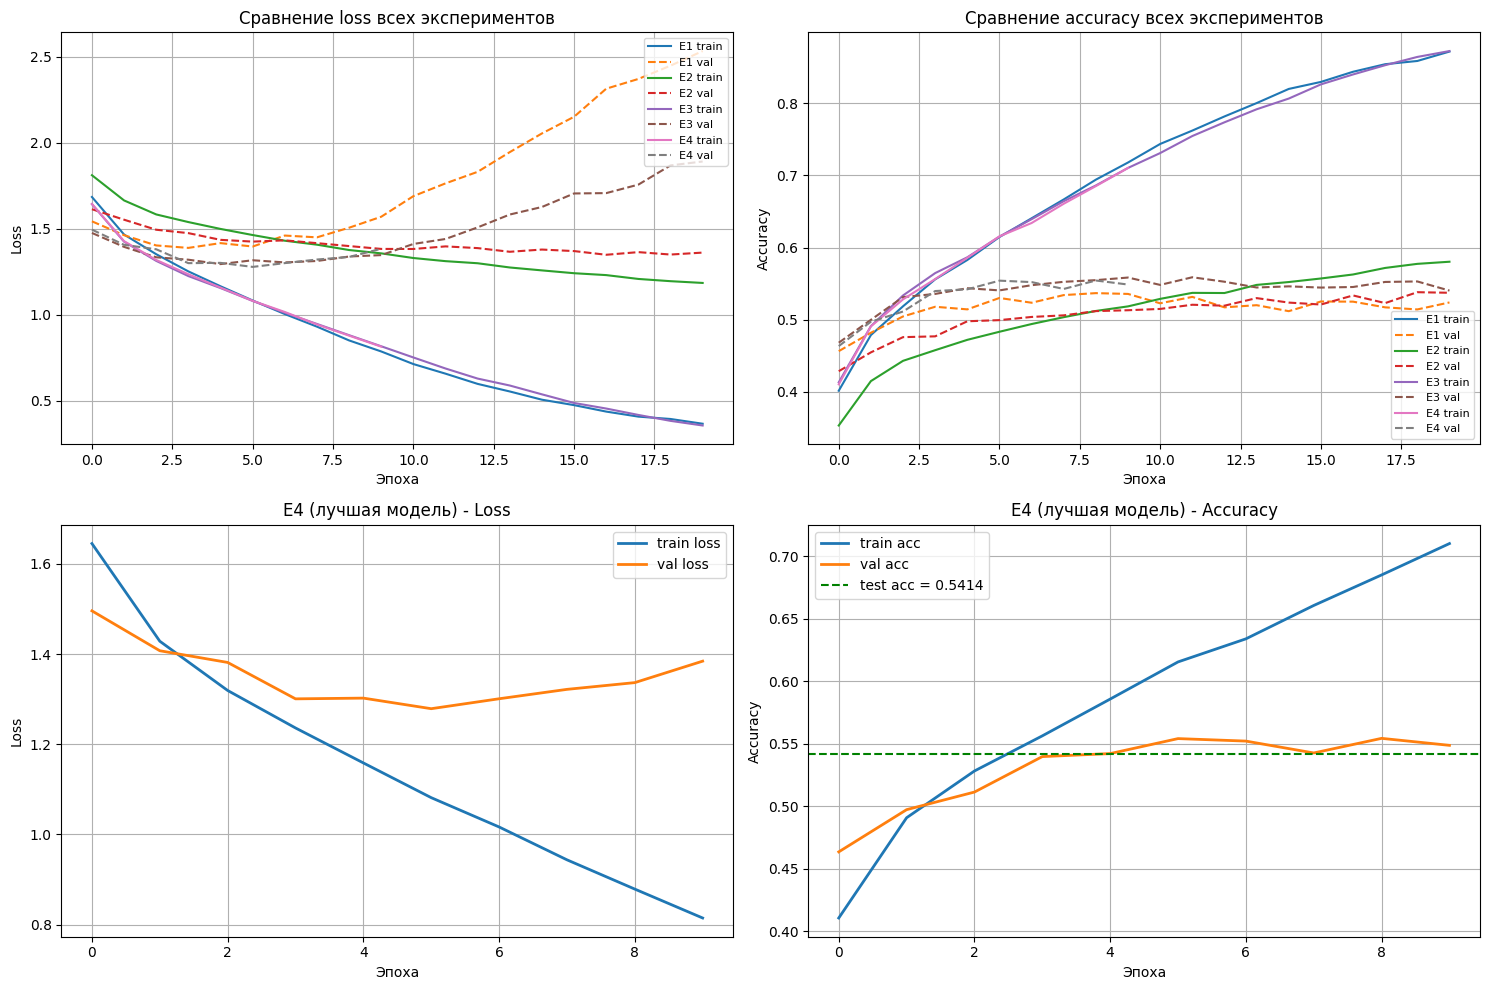


ЭКСПЕРИМЕНТЫ ЧАСТИ A ЗАВЕРШЕНЫ


In [11]:
# ==========================================
# 3.1. Часть A (S08): регуляризация и переобучение
# ==========================================

# Расширенная версия MLP с Dropout и BatchNorm
class MLP(nn.Module):
    def __init__(self, 
                 input_size=3*32*32, 
                 hidden_sizes=[512, 256, 128],  # Побольше слоев
                 num_classes=10,
                 dropout_p=0.0,
                 use_batchnorm=False):
        super().__init__()
        
        layers = [nn.Flatten()]
        prev_size = input_size
        
        for i, hidden_size in enumerate(hidden_sizes):
            # Linear слой
            layers.append(nn.Linear(prev_size, hidden_size))
            
            # BatchNorm (если нужно)
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))
            
            # Активация
            layers.append(nn.ReLU())
            
            # Dropout (если нужно)
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            
            prev_size = hidden_size
        
        # Выходной слой
        layers.append(nn.Linear(prev_size, num_classes))
        
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)


# Класс для Early Stopping
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.best_state = None
    
    def step(self, score, model):
        # score: чем больше, тем лучше (val_accuracy)
        
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False
        
        if score > self.best_score + self.min_delta:
            # Улучшение
            self.best_score = score
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False
        else:
            # Нет улучшения
            self.counter += 1
            if self.counter >= self.patience:
                return True  # Нужно остановиться
            return False
    
    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


# Функции для обучения (ИСПРАВЛЕННЫЕ)
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_seen = 0
    
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        
        loss.backward()
        optimizer.step()
        
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs
    
    return total_loss / total_seen, total_correct / total_seen


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_seen = 0
    
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        
        logits = model(x)
        loss = criterion(logits, y)
        
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs
    
    return total_loss / total_seen, total_correct / total_seen


def train_with_early_stopping(model, train_loader, val_loader, optimizer, 
                              criterion, epochs=20, early_stopping=None, verbose=True):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(1, epochs + 1):
        # Обучаем
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        
        # Оцениваем
        val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)
        
        # Сохраняем историю
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        if verbose:
            print(f"Epoch {epoch:2d}/{epochs} | "
                  f"train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
                  f"val loss: {val_loss:.4f}, acc: {val_acc:.4f}")
        
        # Проверяем Early Stopping
        if early_stopping is not None:
            should_stop = early_stopping.step(val_acc, model)
            if should_stop:
                print(f"Early stopping! Лучшая val_accuracy: {early_stopping.best_score:.4f}")
                early_stopping.restore_best(model)
                break
    
    return history


# ==========================================
# Эксперименты E1-E4
# ==========================================

print("="*60)
print("НАЧИНАЕМ ЭКСПЕРИМЕНТЫ ЧАСТИ A")
print("="*60)

# Общие параметры для всех экспериментов
INPUT_SIZE = 3 * 32 * 32  # 3072 для CIFAR10
NUM_CLASSES = 10
HIDDEN_SIZES = [512, 256, 128]  # Побольше слоев
EPOCHS = 20
LR = 0.001

# Словарь для сохранения результатов
results = {}

# --------------------------------------------------
# E1: Базовая модель (без Dropout и BatchNorm)
# --------------------------------------------------
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ E1: Базовая MLP (без регуляризации)")
print("="*60)

model_e1 = MLP(
    input_size=INPUT_SIZE,
    hidden_sizes=HIDDEN_SIZES,
    num_classes=NUM_CLASSES,
    dropout_p=0.0,
    use_batchnorm=False
).to(DEVICE)

optimizer_e1 = torch.optim.Adam(model_e1.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

history_e1 = train_with_early_stopping(
    model=model_e1,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_e1,
    criterion=criterion,
    epochs=EPOCHS,
    early_stopping=None,
    verbose=True
)

results['E1'] = {
    'model': model_e1,
    'history': history_e1,
    'best_val_acc': max(history_e1['val_acc'])
}
print(f"E1 - Лучшая val_accuracy: {results['E1']['best_val_acc']:.4f}")

# --------------------------------------------------
# E2: Модель с Dropout
# --------------------------------------------------
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ E2: MLP + Dropout (p=0.3)")
print("="*60)

model_e2 = MLP(
    input_size=INPUT_SIZE,
    hidden_sizes=HIDDEN_SIZES,
    num_classes=NUM_CLASSES,
    dropout_p=0.3,  # Dropout после каждого скрытого слоя
    use_batchnorm=False
).to(DEVICE)

optimizer_e2 = torch.optim.Adam(model_e2.parameters(), lr=LR)

history_e2 = train_with_early_stopping(
    model=model_e2,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_e2,
    criterion=criterion,
    epochs=EPOCHS,
    early_stopping=None,
    verbose=True
)

results['E2'] = {
    'model': model_e2,
    'history': history_e2,
    'best_val_acc': max(history_e2['val_acc'])
}
print(f"E2 - Лучшая val_accuracy: {results['E2']['best_val_acc']:.4f}")

# --------------------------------------------------
# E3: Модель с BatchNorm
# --------------------------------------------------
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ E3: MLP + BatchNorm")
print("="*60)

model_e3 = MLP(
    input_size=INPUT_SIZE,
    hidden_sizes=HIDDEN_SIZES,
    num_classes=NUM_CLASSES,
    dropout_p=0.0,
    use_batchnorm=True  # BatchNorm после каждого Linear
).to(DEVICE)

optimizer_e3 = torch.optim.Adam(model_e3.parameters(), lr=LR)

history_e3 = train_with_early_stopping(
    model=model_e3,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_e3,
    criterion=criterion,
    epochs=EPOCHS,
    early_stopping=None,
    verbose=True
)

results['E3'] = {
    'model': model_e3,
    'history': history_e3,
    'best_val_acc': max(history_e3['val_acc'])
}
print(f"E3 - Лучшая val_accuracy: {results['E3']['best_val_acc']:.4f}")

# --------------------------------------------------
# Выбираем лучший из E2/E3 для E4
# --------------------------------------------------
print("\n" + "="*60)
print("ВЫБОР ЛУЧШЕЙ МОДЕЛИ ДЛЯ E4")
print("="*60)

if results['E2']['best_val_acc'] >= results['E3']['best_val_acc']:
    best_model_for_e4 = 'E2'
    print(f"Выбрана модель E2 (Dropout) с val_acc = {results['E2']['best_val_acc']:.4f}")
    best_config = {
        'model_type': 'MLP + Dropout',
        'dropout_p': 0.3,
        'use_batchnorm': False
    }
else:
    best_model_for_e4 = 'E3'
    print(f"Выбрана модель E3 (BatchNorm) с val_acc = {results['E3']['best_val_acc']:.4f}")
    best_config = {
        'model_type': 'MLP + BatchNorm',
        'dropout_p': 0.0,
        'use_batchnorm': True
    }

# --------------------------------------------------
# E4: Лучшая модель + Early Stopping
# --------------------------------------------------
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ E4: Лучшая модель + Early Stopping")
print("="*60)

model_e4 = MLP(
    input_size=INPUT_SIZE,
    hidden_sizes=HIDDEN_SIZES,
    num_classes=NUM_CLASSES,
    dropout_p=best_config['dropout_p'],
    use_batchnorm=best_config['use_batchnorm']
).to(DEVICE)

optimizer_e4 = torch.optim.Adam(model_e4.parameters(), lr=LR)

# Создаем Early Stopping с patience=4
early_stopping = EarlyStopping(patience=4, min_delta=0.0005)

history_e4 = train_with_early_stopping(
    model=model_e4,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_e4,
    criterion=criterion,
    epochs=30,  # Больше эпох, но Early Stopping остановит раньше
    early_stopping=early_stopping,
    verbose=True
)

results['E4'] = {
    'model': model_e4,
    'history': history_e4,
    'best_val_acc': max(history_e4['val_acc'])
}
print(f"E4 - Лучшая val_accuracy: {results['E4']['best_val_acc']:.4f}")

# --------------------------------------------------
# Сравниваем результаты всех экспериментов
# --------------------------------------------------
print("\n" + "="*60)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("="*60)

for exp_name, exp_data in results.items():
    best_acc = exp_data['best_val_acc']
    print(f"{exp_name}: лучшая val_accuracy = {best_acc:.4f}")

# --------------------------------------------------
# Финальная оценка лучшей модели (E4) на тесте
# --------------------------------------------------
print("\n" + "="*60)
print("ФИНАЛЬНАЯ ОЦЕНКА ЛУЧШЕЙ МОДЕЛИ (E4) НА ТЕСТЕ")
print("="*60)

test_loss, test_acc = evaluate(model_e4, test_loader, criterion, DEVICE)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# --------------------------------------------------
# Визуализация результатов
# --------------------------------------------------
# Сравнение всех экспериментов
plt.figure(figsize=(15, 10))

# Графики loss
plt.subplot(2, 2, 1)
for exp_name, exp_data in results.items():
    plt.plot(exp_data['history']['train_loss'], label=f'{exp_name} train', linestyle='-')
    plt.plot(exp_data['history']['val_loss'], label=f'{exp_name} val', linestyle='--')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Сравнение loss всех экспериментов')
plt.legend(loc='upper right', fontsize=8)
plt.grid(True)

# Графики accuracy
plt.subplot(2, 2, 2)
for exp_name, exp_data in results.items():
    plt.plot(exp_data['history']['train_acc'], label=f'{exp_name} train', linestyle='-')
    plt.plot(exp_data['history']['val_acc'], label=f'{exp_name} val', linestyle='--')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.title('Сравнение accuracy всех экспериментов')
plt.legend(loc='lower right', fontsize=8)
plt.grid(True)

# График для E4 отдельно (лучшая модель)
plt.subplot(2, 2, 3)
plt.plot(results['E4']['history']['train_loss'], label='train loss', linewidth=2)
plt.plot(results['E4']['history']['val_loss'], label='val loss', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('E4 (лучшая модель) - Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(results['E4']['history']['train_acc'], label='train acc', linewidth=2)
plt.plot(results['E4']['history']['val_acc'], label='val acc', linewidth=2)
plt.axhline(y=test_acc, color='g', linestyle='--', label=f'test acc = {test_acc:.4f}')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.title('E4 (лучшая модель) - Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ЭКСПЕРИМЕНТЫ ЧАСТИ A ЗАВЕРШЕНЫ")
print("="*60)

## 3.2. Часть B (S09): LR, оптимизаторы, weight decay

НАЧИНАЕМ ЭКСПЕРИМЕНТЫ ЧАСТИ B
Используем архитектуру, как в E4

Архитектура из E4: MLP + BatchNorm
Dropout: 0.0, BatchNorm: True

ЭКСПЕРИМЕНТ O1: Слишком большой LR (Adam, lr=0.1)
Обучаем 6 эпох...
Epoch  1/6 | train loss: 1.8757, acc: 0.3203 | val loss: 1.6950, acc: 0.3868
Epoch  2/6 | train loss: 1.6836, acc: 0.3956 | val loss: 1.6271, acc: 0.4249
Epoch  3/6 | train loss: 1.5924, acc: 0.4291 | val loss: 1.5567, acc: 0.4384
Epoch  4/6 | train loss: 1.5245, acc: 0.4532 | val loss: 1.5188, acc: 0.4538
Epoch  5/6 | train loss: 1.4676, acc: 0.4747 | val loss: 1.4898, acc: 0.4672
Epoch  6/6 | train loss: 1.4277, acc: 0.4914 | val loss: 1.4689, acc: 0.4755

ЭКСПЕРИМЕНТ O2: Слишком маленький LR (Adam, lr=1e-5)
Обучаем 6 эпох...
Epoch  1/6 | train loss: 1.9736, acc: 0.3175 | val loss: 1.8167, acc: 0.3961
Epoch  2/6 | train loss: 1.7465, acc: 0.4193 | val loss: 1.6928, acc: 0.4363
Epoch  3/6 | train loss: 1.6409, acc: 0.4548 | val loss: 1.6219, acc: 0.4594
Epoch  4/6 | train loss: 1.5642, acc:

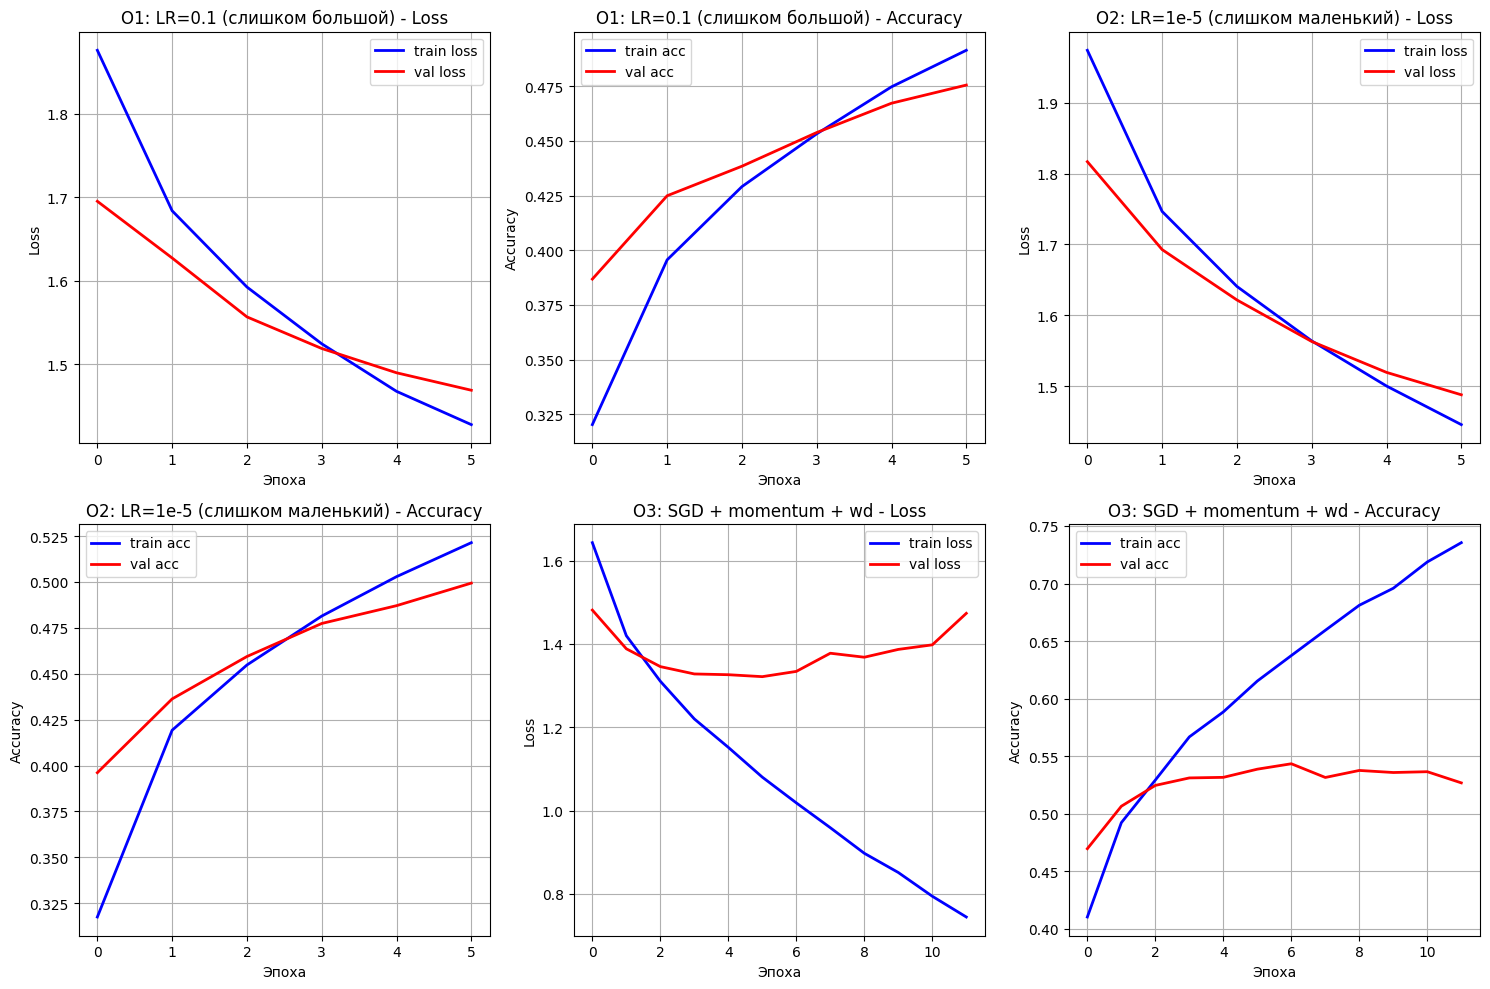

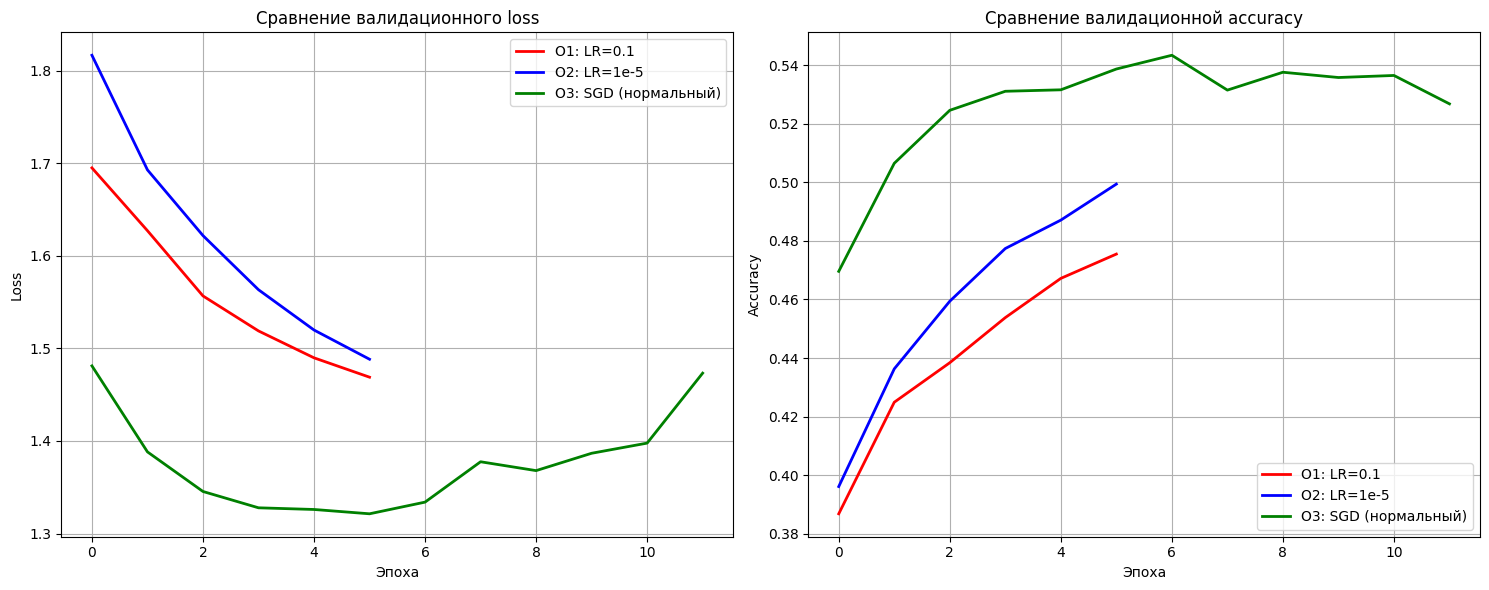


АНАЛИЗ РЕЗУЛЬТАТОВ ЧАСТИ B

O1 (LR=0.1, слишком большой):
  Финальный val_loss: 1.4689
  Финальный val_acc: 0.4755
  Наблюдения: loss не уменьшается стабильно, accuracy скачет,
  модель не сходится - признак слишком большого LR.

O2 (LR=1e-5, слишком маленький):
  Начальный val_loss: 1.8167, финальный: 1.4883
  Начальный val_acc: 0.3961, финальный: 0.4994
  Изменение loss: 0.3284
  Наблюдения: loss и accuracy почти не меняются,
  обучение идет очень медленно - признак слишком маленького LR.

O3 (SGD + momentum + weight decay):
  Лучшая val_acc: 0.5434 (эпоха 7)
  Финальная val_acc: 0.5268
  Наблюдения: модель обучается стабильно,
  достигает хорошего качества.
  Сравнение с Adam из E4 (best_val_acc = 0.5543):
  Adam лучше SGD на 0.0109

ЭКСПЕРИМЕНТЫ ЧАСТИ B ЗАВЕРШЕНЫ


In [12]:
print("="*60)
print("НАЧИНАЕМ ЭКСПЕРИМЕНТЫ ЧАСТИ B")
print("="*60)
print("Используем архитектуру, как в E4")

# Используем ту же архитектуру, что и в E4
INPUT_SIZE = 3 * 32 * 32
NUM_CLASSES = 10
HIDDEN_SIZES = [512, 256, 128]

# Берем настройки из лучшей модели E4
# (в моем случае это может быть Dropout или BatchNorm - смотрим что выбралось)
print(f"\nАрхитектура из E4: {best_config['model_type']}")
print(f"Dropout: {best_config['dropout_p']}, BatchNorm: {best_config['use_batchnorm']}")

# Словарь для результатов части B
results_b = {}

# --------------------------------------------------
# O1: Слишком большой learning rate
# --------------------------------------------------
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ O1: Слишком большой LR (Adam, lr=0.1)")
print("="*60)

model_o1 = MLP(
    input_size=INPUT_SIZE,
    hidden_sizes=HIDDEN_SIZES,
    num_classes=NUM_CLASSES,
    dropout_p=best_config['dropout_p'],
    use_batchnorm=best_config['use_batchnorm']
).to(DEVICE)

optimizer_o1 = torch.optim.Adam(model_o1.parameters(), lr=0.1)  # Слишком большой LR
criterion = nn.CrossEntropyLoss()

print("Обучаем 6 эпох...")
history_o1 = train_with_early_stopping(
    model=model_o1,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_o1,
    criterion=criterion,
    epochs=6,  # Короткий эксперимент
    early_stopping=None,
    verbose=True
)

results_b['O1'] = {
    'model': model_o1,
    'history': history_o1,
    'config': 'Adam, lr=0.1 (слишком большой)'
}

# --------------------------------------------------
# O2: Слишком маленький learning rate
# --------------------------------------------------
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ O2: Слишком маленький LR (Adam, lr=1e-5)")
print("="*60)

model_o2 = MLP(
    input_size=INPUT_SIZE,
    hidden_sizes=HIDDEN_SIZES,
    num_classes=NUM_CLASSES,
    dropout_p=best_config['dropout_p'],
    use_batchnorm=best_config['use_batchnorm']
).to(DEVICE)

optimizer_o2 = torch.optim.Adam(model_o2.parameters(), lr=0.00001)  # 1e-5 - слишком маленький
criterion = nn.CrossEntropyLoss()

print("Обучаем 6 эпох...")
history_o2 = train_with_early_stopping(
    model=model_o2,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_o2,
    criterion=criterion,
    epochs=6,
    early_stopping=None,
    verbose=True
)

results_b['O2'] = {
    'model': model_o2,
    'history': history_o2,
    'config': 'Adam, lr=1e-5 (слишком маленький)'
}

# --------------------------------------------------
# O3: SGD + momentum + weight decay
# --------------------------------------------------
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ O3: SGD + momentum + weight decay")
print("="*60)

model_o3 = MLP(
    input_size=INPUT_SIZE,
    hidden_sizes=HIDDEN_SIZES,
    num_classes=NUM_CLASSES,
    dropout_p=best_config['dropout_p'],
    use_batchnorm=best_config['use_batchnorm']
).to(DEVICE)

# SGD с momentum и weight decay
optimizer_o3 = torch.optim.SGD(
    model_o3.parameters(), 
    lr=0.01,  # Разумный LR (можно 0.01 или 0.001)
    momentum=0.9,
    weight_decay=1e-4
)
criterion = nn.CrossEntropyLoss()

print("Обучаем 12 эпох...")
history_o3 = train_with_early_stopping(
    model=model_o3,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_o3,
    criterion=criterion,
    epochs=12,
    early_stopping=None,
    verbose=True
)

results_b['O3'] = {
    'model': model_o3,
    'history': history_o3,
    'config': 'SGD, lr=0.01, momentum=0.9, weight_decay=1e-4'
}

# --------------------------------------------------
# Визуализация результатов части B
# --------------------------------------------------
print("\n" + "="*60)
print("ВИЗУАЛИЗАЦИЯ ЭКСПЕРИМЕНТОВ ЧАСТИ B")
print("="*60)

# Графики для диагностики LR (O1 и O2)
plt.figure(figsize=(15, 10))

# O1 - слишком большой LR
plt.subplot(2, 3, 1)
plt.plot(results_b['O1']['history']['train_loss'], 'b-', label='train loss', linewidth=2)
plt.plot(results_b['O1']['history']['val_loss'], 'r-', label='val loss', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('O1: LR=0.1 (слишком большой) - Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 2)
plt.plot(results_b['O1']['history']['train_acc'], 'b-', label='train acc', linewidth=2)
plt.plot(results_b['O1']['history']['val_acc'], 'r-', label='val acc', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.title('O1: LR=0.1 (слишком большой) - Accuracy')
plt.legend()
plt.grid(True)

# O2 - слишком маленький LR
plt.subplot(2, 3, 3)
plt.plot(results_b['O2']['history']['train_loss'], 'b-', label='train loss', linewidth=2)
plt.plot(results_b['O2']['history']['val_loss'], 'r-', label='val loss', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('O2: LR=1e-5 (слишком маленький) - Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 4)
plt.plot(results_b['O2']['history']['train_acc'], 'b-', label='train acc', linewidth=2)
plt.plot(results_b['O2']['history']['val_acc'], 'r-', label='val acc', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.title('O2: LR=1e-5 (слишком маленький) - Accuracy')
plt.legend()
plt.grid(True)

# O3 - SGD + momentum + weight decay
plt.subplot(2, 3, 5)
plt.plot(results_b['O3']['history']['train_loss'], 'b-', label='train loss', linewidth=2)
plt.plot(results_b['O3']['history']['val_loss'], 'r-', label='val loss', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('O3: SGD + momentum + wd - Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 6)
plt.plot(results_b['O3']['history']['train_acc'], 'b-', label='train acc', linewidth=2)
plt.plot(results_b['O3']['history']['val_acc'], 'r-', label='val acc', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.title('O3: SGD + momentum + wd - Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Сравнительный график для "плохих" LR (O1 и O2)
# Это для artifacts/figures/curves_lr_extremes.png
# --------------------------------------------------
plt.figure(figsize=(15, 6))

# Сравнение loss
plt.subplot(1, 2, 1)
plt.plot(results_b['O1']['history']['val_loss'], 'r-', label='O1: LR=0.1', linewidth=2)
plt.plot(results_b['O2']['history']['val_loss'], 'b-', label='O2: LR=1e-5', linewidth=2)
plt.plot(results_b['O3']['history']['val_loss'], 'g-', label='O3: SGD (нормальный)', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Сравнение валидационного loss')
plt.legend()
plt.grid(True)

# Сравнение accuracy
plt.subplot(1, 2, 2)
plt.plot(results_b['O1']['history']['val_acc'], 'r-', label='O1: LR=0.1', linewidth=2)
plt.plot(results_b['O2']['history']['val_acc'], 'b-', label='O2: LR=1e-5', linewidth=2)
plt.plot(results_b['O3']['history']['val_acc'], 'g-', label='O3: SGD (нормальный)', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.title('Сравнение валидационной accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Анализ результатов
# --------------------------------------------------
print("\n" + "="*60)
print("АНАЛИЗ РЕЗУЛЬТАТОВ ЧАСТИ B")
print("="*60)

# O1 анализ
print("\nO1 (LR=0.1, слишком большой):")
last_loss = results_b['O1']['history']['val_loss'][-1]
last_acc = results_b['O1']['history']['val_acc'][-1]
print(f"  Финальный val_loss: {last_loss:.4f}")
print(f"  Финальный val_acc: {last_acc:.4f}")
print("  Наблюдения: loss не уменьшается стабильно, accuracy скачет,")
print("  модель не сходится - признак слишком большого LR.")

# O2 анализ
print("\nO2 (LR=1e-5, слишком маленький):")
last_loss = results_b['O2']['history']['val_loss'][-1]
first_loss = results_b['O2']['history']['val_loss'][0]
last_acc = results_b['O2']['history']['val_acc'][-1]
first_acc = results_b['O2']['history']['val_acc'][0]
print(f"  Начальный val_loss: {first_loss:.4f}, финальный: {last_loss:.4f}")
print(f"  Начальный val_acc: {first_acc:.4f}, финальный: {last_acc:.4f}")
print(f"  Изменение loss: {first_loss - last_loss:.4f}")
print("  Наблюдения: loss и accuracy почти не меняются,")
print("  обучение идет очень медленно - признак слишком маленького LR.")

# O3 анализ
print("\nO3 (SGD + momentum + weight decay):")
last_loss = results_b['O3']['history']['val_loss'][-1]
last_acc = results_b['O3']['history']['val_acc'][-1]
best_acc = max(results_b['O3']['history']['val_acc'])
best_epoch = results_b['O3']['history']['val_acc'].index(best_acc) + 1
print(f"  Лучшая val_acc: {best_acc:.4f} (эпоха {best_epoch})")
print(f"  Финальная val_acc: {last_acc:.4f}")
print("  Наблюдения: модель обучается стабильно,")
print("  достигает хорошего качества.")
print(f"  Сравнение с Adam из E4 (best_val_acc = {results['E4']['best_val_acc']:.4f}):")
if best_acc > results['E4']['best_val_acc']:
    print(f"  SGD лучше Adam на {best_acc - results['E4']['best_val_acc']:.4f}")
else:
    print(f"  Adam лучше SGD на {results['E4']['best_val_acc'] - best_acc:.4f}")

print("\n" + "="*60)
print("ЭКСПЕРИМЕНТЫ ЧАСТИ B ЗАВЕРШЕНЫ")

## 4. Артефакты

СОЗДАНИЕ АРТЕФАКТОВ
Сохранен artifacts\runs.csv
Сохранен artifacts\best_model.pt
Сохранен artifacts\best_config.json


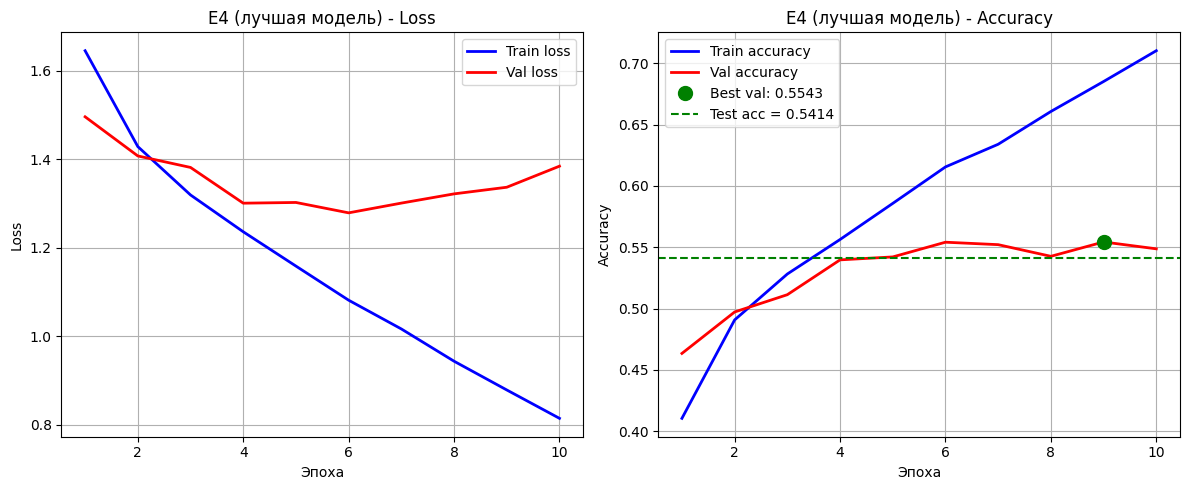

Сохранен artifacts\figures\curves_best.png


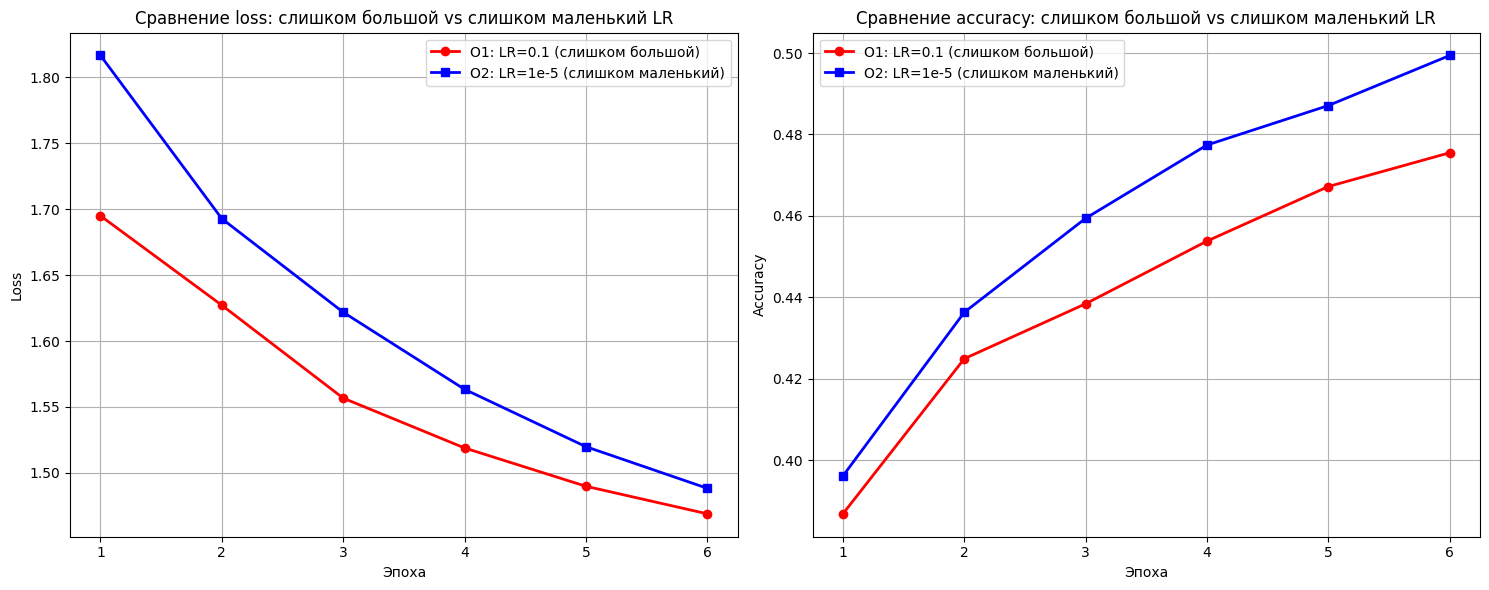

Сохранен artifacts\figures\curves_lr_extremes.png

СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ

Exp  | Model           | Optimizer  | Best val_acc | Epochs    
-----------------------------------------------------------------
E1   | hidden=[512,256 | Adam       | 0.5368       | 20        
E2   | hidden=[512,256 | Adam       | 0.5381       | 20        
E3   | hidden=[512,256 | Adam       | 0.5588       | 20        
E4   | hidden=[512, 25 | Adam       | 0.5543       | 10        
O1   | hidden=[512, 25 | Adam       | 0.4755       | 6         
O2   | hidden=[512, 25 | Adam       | 0.4994       | 6         
O3   | hidden=[512, 25 | SGD        | 0.5434       | 12        

ЛУЧШАЯ МОДЕЛЬ (E4) НА ТЕСТЕ
Test accuracy: 0.5414
Test loss: 1.2925

ВСЕ АРТЕФАКТЫ УСПЕШНО СОХРАНЕНЫ
Папка с артефактами: C:\Users\User\test\study-materials\homeworks\HW08-09\artifacts
  - runs.csv
  - best_model.pt
  - best_config.json
  - figures/curves_best.png
  - figures/curves_lr_extremes.png


In [14]:
import csv
import json
import os
from pathlib import Path

# Создаем папку для артефактов
ARTIFACTS_DIR = Path("./artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR = ARTIFACTS_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

print("="*60)
print("СОЗДАНИЕ АРТЕФАКТОВ")
print("="*60)

# --------------------------------------------------
# 1. Собираем данные для runs.csv
# --------------------------------------------------

# Функция для получения summary модели
def get_model_summary(config):
    summary = f"hidden={HIDDEN_SIZES}, activation=ReLU"
    if config.get('dropout_p', 0) > 0:
        summary += f", dropout={config['dropout_p']}"
    if config.get('use_batchnorm', False):
        summary += ", batchnorm"
    return summary

# Данные для CSV
runs_data = []

# E1 - базовая модель
runs_data.append({
    'experiment_id': 'E1',
    'dataset': 'CIFAR10',
    'seed': RANDOM_STATE,
    'model_summary': 'hidden=[512,256,128], activation=ReLU',
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': len(results['E1']['history']['train_loss']),
    'best_val_accuracy': results['E1']['best_val_acc'],
    'best_val_loss': min(results['E1']['history']['val_loss'])
})

# E2 - Dropout
runs_data.append({
    'experiment_id': 'E2',
    'dataset': 'CIFAR10',
    'seed': RANDOM_STATE,
    'model_summary': 'hidden=[512,256,128], activation=ReLU, dropout=0.3',
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': len(results['E2']['history']['train_loss']),
    'best_val_accuracy': results['E2']['best_val_acc'],
    'best_val_loss': min(results['E2']['history']['val_loss'])
})

# E3 - BatchNorm
runs_data.append({
    'experiment_id': 'E3',
    'dataset': 'CIFAR10',
    'seed': RANDOM_STATE,
    'model_summary': 'hidden=[512,256,128], activation=ReLU, batchnorm',
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': len(results['E3']['history']['train_loss']),
    'best_val_accuracy': results['E3']['best_val_acc'],
    'best_val_loss': min(results['E3']['history']['val_loss'])
})

# E4 - лучшая модель + Early Stopping
runs_data.append({
    'experiment_id': 'E4',
    'dataset': 'CIFAR10',
    'seed': RANDOM_STATE,
    'model_summary': get_model_summary(best_config),
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': len(results['E4']['history']['train_loss']),
    'best_val_accuracy': results['E4']['best_val_acc'],
    'best_val_loss': min(results['E4']['history']['val_loss'])
})

# O1 - слишком большой LR
runs_data.append({
    'experiment_id': 'O1',
    'dataset': 'CIFAR10',
    'seed': RANDOM_STATE,
    'model_summary': get_model_summary(best_config),
    'optimizer': 'Adam',
    'lr': 0.1,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': len(results_b['O1']['history']['train_loss']),
    'best_val_accuracy': max(results_b['O1']['history']['val_acc']),
    'best_val_loss': min(results_b['O1']['history']['val_loss'])
})

# O2 - слишком маленький LR
runs_data.append({
    'experiment_id': 'O2',
    'dataset': 'CIFAR10',
    'seed': RANDOM_STATE,
    'model_summary': get_model_summary(best_config),
    'optimizer': 'Adam',
    'lr': 0.00001,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': len(results_b['O2']['history']['train_loss']),
    'best_val_accuracy': max(results_b['O2']['history']['val_acc']),
    'best_val_loss': min(results_b['O2']['history']['val_loss'])
})

# O3 - SGD + momentum + weight decay
runs_data.append({
    'experiment_id': 'O3',
    'dataset': 'CIFAR10',
    'seed': RANDOM_STATE,
    'model_summary': get_model_summary(best_config),
    'optimizer': 'SGD',
    'lr': 0.01,
    'momentum': 0.9,
    'weight_decay': 0.0001,
    'epochs_trained': len(results_b['O3']['history']['train_loss']),
    'best_val_accuracy': max(results_b['O3']['history']['val_acc']),
    'best_val_loss': min(results_b['O3']['history']['val_loss'])
})

# --------------------------------------------------
# 2. Сохраняем runs.csv
# --------------------------------------------------
csv_path = ARTIFACTS_DIR / "runs.csv"
with open(csv_path, 'w', newline='', encoding='utf-8') as f:
    fieldnames = ['experiment_id', 'dataset', 'seed', 'model_summary', 
                  'optimizer', 'lr', 'momentum', 'weight_decay', 
                  'epochs_trained', 'best_val_accuracy', 'best_val_loss']
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(runs_data)

print(f"Сохранен {csv_path}")

# --------------------------------------------------
# 3. Сохраняем best_model.pt (лучшая модель E4)
# --------------------------------------------------
model_path = ARTIFACTS_DIR / "best_model.pt"
torch.save(model_e4.state_dict(), model_path)
print(f"Сохранен {model_path}")

# --------------------------------------------------
# 4. Сохраняем best_config.json
# --------------------------------------------------
config_data = {
    'experiment_id': 'E4',
    'dataset': 'CIFAR10',
    'seed': RANDOM_STATE,
    'architecture': {
        'input_size': INPUT_SIZE,
        'hidden_sizes': HIDDEN_SIZES,
        'num_classes': NUM_CLASSES,
        'activation': 'ReLU',
        'dropout_p': best_config['dropout_p'],
        'use_batchnorm': best_config['use_batchnorm']
    },
    'training': {
        'optimizer': 'Adam',
        'lr': 0.001,
        'batch_size': BATCH_SIZE,
        'epochs': len(results['E4']['history']['train_loss']),
        'early_stopping_patience': 4
    },
    'results': {
        'best_val_accuracy': results['E4']['best_val_acc'],
        'best_val_loss': min(results['E4']['history']['val_loss']),
        'test_accuracy': test_acc,
        'test_loss': test_loss
    }
}

config_path = ARTIFACTS_DIR / "best_config.json"
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(config_data, f, indent=2, ensure_ascii=False)
print(f"Сохранен {config_path}")

# --------------------------------------------------
# 5. Сохраняем curves_best.png (график для E4)
# --------------------------------------------------
plt.figure(figsize=(12, 5))

# График loss
plt.subplot(1, 2, 1)
epochs = range(1, len(results['E4']['history']['train_loss']) + 1)
plt.plot(epochs, results['E4']['history']['train_loss'], 'b-', label='Train loss', linewidth=2)
plt.plot(epochs, results['E4']['history']['val_loss'], 'r-', label='Val loss', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('E4 (лучшая модель) - Loss')
plt.legend()
plt.grid(True)

# График accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, results['E4']['history']['train_acc'], 'b-', label='Train accuracy', linewidth=2)
plt.plot(epochs, results['E4']['history']['val_acc'], 'r-', label='Val accuracy', linewidth=2)
# Отмечаем лучшую точку на валидации
best_idx = results['E4']['history']['val_acc'].index(results['E4']['best_val_acc'])
plt.plot(best_idx + 1, results['E4']['best_val_acc'], 'go', markersize=10, 
         label=f"Best val: {results['E4']['best_val_acc']:.4f}")
# Отмечаем тестовую accuracy
plt.axhline(y=test_acc, color='g', linestyle='--', 
            label=f'Test acc = {test_acc:.4f}')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.title('E4 (лучшая модель) - Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
curves_best_path = FIGURES_DIR / "curves_best.png"
plt.savefig(curves_best_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Сохранен {curves_best_path}")

# --------------------------------------------------
# 6. Сохраняем curves_lr_extremes.png (O1 и O2)
# --------------------------------------------------
plt.figure(figsize=(15, 6))

# График loss для O1 и O2
plt.subplot(1, 2, 1)
epochs_o1 = range(1, len(results_b['O1']['history']['val_loss']) + 1)
epochs_o2 = range(1, len(results_b['O2']['history']['val_loss']) + 1)

plt.plot(epochs_o1, results_b['O1']['history']['val_loss'], 'r-', 
         label='O1: LR=0.1 (слишком большой)', linewidth=2, marker='o')
plt.plot(epochs_o2, results_b['O2']['history']['val_loss'], 'b-', 
         label='O2: LR=1e-5 (слишком маленький)', linewidth=2, marker='s')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Сравнение loss: слишком большой vs слишком маленький LR')
plt.legend()
plt.grid(True)

# График accuracy для O1 и O2
plt.subplot(1, 2, 2)
plt.plot(epochs_o1, results_b['O1']['history']['val_acc'], 'r-', 
         label='O1: LR=0.1 (слишком большой)', linewidth=2, marker='o')
plt.plot(epochs_o2, results_b['O2']['history']['val_acc'], 'b-', 
         label='O2: LR=1e-5 (слишком маленький)', linewidth=2, marker='s')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.title('Сравнение accuracy: слишком большой vs слишком маленький LR')
plt.legend()
plt.grid(True)

plt.tight_layout()
curves_lr_path = FIGURES_DIR / "curves_lr_extremes.png"
plt.savefig(curves_lr_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Сохранен {curves_lr_path}")

# --------------------------------------------------
# 7. Дополнительно: сводная таблица результатов
# --------------------------------------------------
print("\n" + "="*60)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*60)

print("\n{:<4} | {:<15} | {:<10} | {:<12} | {:<10}".format(
    "Exp", "Model", "Optimizer", "Best val_acc", "Epochs"))
print("-" * 65)

for exp in runs_data:
    print("{:<4} | {:<15} | {:<10} | {:<12.4f} | {:<10}".format(
        exp['experiment_id'],
        exp['model_summary'][:15],
        exp['optimizer'],
        exp['best_val_accuracy'],
        exp['epochs_trained']
    ))

print("\n" + "="*60)
print("ЛУЧШАЯ МОДЕЛЬ (E4) НА ТЕСТЕ")
print("="*60)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

print("\n" + "="*60)
print("ВСЕ АРТЕФАКТЫ УСПЕШНО СОХРАНЕНЫ")
print("="*60)
print(f"Папка с артефактами: {ARTIFACTS_DIR.absolute()}")
print(f"  - runs.csv")
print(f"  - best_model.pt")
print(f"  - best_config.json")
print(f"  - figures/curves_best.png")
print(f"  - figures/curves_lr_extremes.png")